In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import sqeuclidean
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

In [2]:
class HierarchicalAgglomerativeClustering:
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters

    @staticmethod
    def _ward_distance(c1, c2):
        n1, n2 = len(c1), len(c2)
        c1_mean, c2_mean = np.mean(c1, axis=0), np.mean(c2, axis=0)
        sqeuclidean_dist = sqeuclidean(c1_mean, c2_mean)

        return (n1 * n2) / (n1 + n2) * sqeuclidean_dist

    @staticmethod
    def _update_labels(labels, min_cdist_idxs):
        # assign a cluster number to labels
        labels[labels == min_cdist_idxs[1]] = min_cdist_idxs[0]
        labels[labels > min_cdist_idxs[1]] -= 1

        return labels

    def fit_predict(self, X):
        labels = np.arange(len(X))
        clusters = [[x] for x in X]

        while len(clusters) > self.n_clusters:
            min_cdist, min_cdist_idxs = np.inf, []

            for i in range(len(clusters) - 1):
                for j in range(i + 1, len(clusters)):
                    cdist = self._ward_distance(clusters[i], clusters[j])

                    if cdist < min_cdist:
                        min_cdist = cdist
                        min_cdist_idxs = (i, j)

            labels = self._update_labels(labels, min_cdist_idxs)
            clusters[min_cdist_idxs[0]].extend(clusters.pop(min_cdist_idxs[1]))

        return np.array(labels)

In [3]:
X, y = make_blobs(n_samples=75, n_features=2, centers=5, random_state=0)
print(y)

[0 3 4 3 2 4 0 2 0 4 2 4 2 2 0 0 0 3 2 0 2 2 2 3 4 1 1 2 3 0 4 4 3 3 3 2 2
 0 1 1 3 1 0 2 4 1 4 4 0 4 1 0 3 0 4 1 2 1 4 3 1 1 3 0 3 4 1 2 1 4 0 3 1 1
 3]


In [4]:
agg = HierarchicalAgglomerativeClustering(n_clusters=5)
y_pred = agg.fit_predict(X)
ac_ari = adjusted_rand_score(y, y_pred)
print(f'Adjusted Rand Score for AgglomerativeClustering: {ac_ari}', '', sep='\n')
print('prediction', y_pred, sep='\n')

Adjusted Rand Score for AgglomerativeClustering: 0.8370870157432925

prediction
[0 1 2 0 3 2 0 3 0 2 3 2 3 3 0 0 0 1 3 0 3 3 0 1 2 4 4 3 1 3 2 2 1 1 1 3 3
 0 4 4 1 4 0 3 2 4 2 2 3 2 4 0 1 0 2 4 3 4 2 1 4 4 1 0 1 2 4 3 3 2 0 1 4 4
 1]


Text(0, 0.5, 'Feature 2')

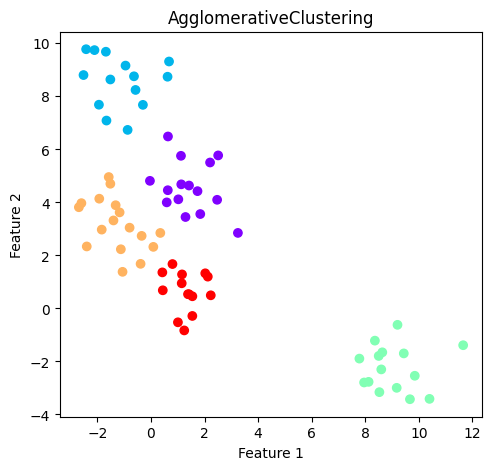

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='rainbow')
plt.title('AgglomerativeClustering')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

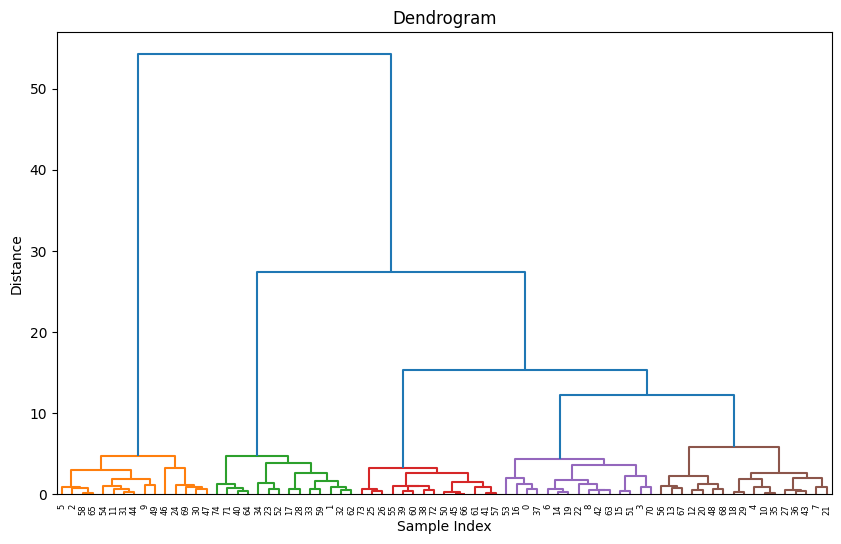

In [8]:
linkage_matrix = linkage(X, method='ward', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, color_threshold=10)
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.title("Dendrogram")
plt.show()